# Test Trace And Answer Analysis

This notebook analyzes the test-set oracle traces and inference runs under:

- `outputs/inference/test_oracle`
- `outputs/oracle_dataset/test`

It is intentionally discovery-driven: it scans the directories, parses run metadata from paths, and builds reusable dataframes for accuracy, trace structure, selected patches/regions, cross-entropy reductions, and correctness-conditioned trace analysis.

In [1]:
%matplotlib inline

from collections import Counter
import json
import math
from pathlib import Path
import re
import statistics

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

ROOT_CANDIDATES = [Path.cwd(), Path.cwd().parent, Path("/home/csalt/Haider/DVLM/lvar")]
ROOT = next((p.resolve() for p in ROOT_CANDIDATES if (p / "outputs/inference/test_oracle").exists()), None)
if ROOT is None:
    raise FileNotFoundError("Could not locate repo root containing outputs/inference/test_oracle")

INFERENCE_ROOT = ROOT / "outputs/inference/test_oracle"
TRACE_ROOT = ROOT / "outputs/oracle_dataset/test"

print(f"ROOT: {ROOT}")
print(f"INFERENCE_ROOT exists: {INFERENCE_ROOT.exists()} -> {INFERENCE_ROOT}")
print(f"TRACE_ROOT exists: {TRACE_ROOT.exists()} -> {TRACE_ROOT}")

ROOT: /home/csalt/Haider/DVLM/lvar
INFERENCE_ROOT exists: True -> /home/csalt/Haider/DVLM/lvar/outputs/inference/test_oracle
TRACE_ROOT exists: True -> /home/csalt/Haider/DVLM/lvar/outputs/oracle_dataset/test


## Helpers

The helpers below normalize naming across paths, load JSONL safely, and derive trace-level metrics from both high-level decisions and primitive trace actions.

In [2]:
def load_json(path):
    path = Path(path)
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def load_jsonl(path):
    path = Path(path)
    rows = []
    bad_rows = []
    with path.open("r", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            stripped = line.strip()
            if not stripped:
                continue
            try:
                rows.append(json.loads(stripped))
            except json.JSONDecodeError as exc:
                bad_rows.append({
                    "path": str(path),
                    "line_number": line_number,
                    "error": str(exc),
                    "context": stripped[max(0, exc.pos - 100): exc.pos + 100],
                })
    return rows, bad_rows


def clean_ckpt_name(value):
    if value is None:
        return None
    value = str(value)
    value = value.replace("mined_by_", "").replace("evaluated_by_", "")
    value = value.replace("_ckpt", "")
    return value


def pretty_variant(value):
    mapping = {
        "raw": "raw",
        "filtered_cap": "filtered (cap)",
        "filtered_no_cap": "filtered (no cap)",
    }
    return mapping.get(str(value), str(value))


def parse_inference_summary_path(path):
    parts = Path(path).parts
    mined_by = next((clean_ckpt_name(p) for p in parts if p.startswith("mined_by_")), None)
    evaluated_by = next((clean_ckpt_name(p) for p in parts if p.startswith("evaluated_by_")), None)
    variant_dir = next((p.replace("trace_variant_", "") for p in parts if p.startswith("trace_variant_")), None)
    return mined_by, evaluated_by, variant_dir


def parse_trace_path(path):
    path = Path(path)
    match = re.search(r"m3cot_test_traces_(?P<mined_by>.+?)_(?P<context>global|coarse)\.jsonl$", path.name)
    mined_by = match.group("mined_by") if match else clean_ckpt_name(path.parent.name)
    context = match.group("context") if match else None
    return clean_ckpt_name(mined_by), context


def action_type(action):
    return str(action.get("type", action.get("action", "UNKNOWN"))).upper()


def action_index(action):
    if "patch_idx" in action:
        return action.get("patch_idx")
    if "patch_index" in action:
        return action.get("patch_index")
    if "region_idx" in action:
        return action.get("region_idx")
    if "region_index" in action:
        return action.get("region_index")
    return None


def decision_reduction(decision):
    if decision.get("improvement") is not None:
        return float(decision.get("improvement"))
    ce_noop = decision.get("ce_noop")
    ce_selected = decision.get("ce_selected")
    if ce_noop is not None and ce_selected is not None:
        return float(ce_noop) - float(ce_selected)
    return np.nan


def finite_mean(values):
    values = [float(v) for v in values if pd.notna(v)]
    return float(np.mean(values)) if values else np.nan


def finite_sum(values):
    values = [float(v) for v in values if pd.notna(v)]
    return float(np.sum(values)) if values else np.nan


def infer_grid_size(indices):
    indices = [int(i) for i in indices if pd.notna(i)]
    if not indices:
        return 1
    return int(math.ceil(math.sqrt(max(indices) + 1)))

## 1. Final Accuracy Across Inference Settings

This scans all `*_summary.json` files in the inference directory and tabulates accuracy by mined checkpoint, context (`global` vs `coarse`), evaluator checkpoint, and trace variant (`raw`, `filtered (cap)`, `filtered (no cap)`).

In [7]:
summary_rows = []
for path in sorted(INFERENCE_ROOT.rglob("*_summary.json")):
    summary = load_json(path)
    mined_by, evaluated_by, variant_from_path = parse_inference_summary_path(path)
    metrics = summary.get("metrics", {}) or {}
    trace_variant = summary.get("trace_variant") or variant_from_path
    summary_rows.append({
        "mined_by": mined_by,
        "context": summary.get("context"),
        # "context_mode": summary.get("context_mode"),
        "evaluated_by": evaluated_by,
        "trace_variant_label": pretty_variant(trace_variant),
        "accuracy": metrics.get("accuracy"),
        "correct": metrics.get("correct"),
        "total": metrics.get("total"),
        "avg_trace_actions": metrics.get("avg_trace_actions"),
        "avg_output_tokens": metrics.get("avg_output_tokens"),
        "kept_primitives": (summary.get("transform_totals") or {}).get("kept_primitives"),
        # "converted_noop_to_stop": (summary.get("transform_totals") or {}).get("converted_noop_to_stop"),
        # "summary_path": str(path.relative_to(ROOT)),
        # "prediction_path": str(Path(summary.get("output_path", "")).as_posix()),
        # "trace_path": str(Path(summary.get("trace_path", "")).as_posix()),
    })

accuracy_df = pd.DataFrame(summary_rows)
if accuracy_df.empty:
    raise ValueError(f"No inference summaries found under {INFERENCE_ROOT}")

accuracy_df = accuracy_df.sort_values(["mined_by", "context", "evaluated_by", "trace_variant_label"]).reset_index(drop=True)
accuracy_df["accuracy"] = 100 * accuracy_df["accuracy"].astype(float)
accuracy_df

,mined_by,context,evaluated_by,trace_variant_label,accuracy,correct,total,avg_trace_actions,avg_output_tokens,kept_primitives
0,ivtlr,coarse,ivtlr,filtered (cap),51.47,1193,2318,7.60,6.06,17621
1,ivtlr,coarse,ivtlr,filtered (no cap),57.51,1333,2318,10.86,6.00,25170
2,ivtlr,coarse,ivtlr,raw,58.67,1360,2318,11.57,6.00,26810
3,ivtlr,coarse,lvar,filtered (cap),42.49,985,2318,7.60,8.16,17621
4,ivtlr,coarse,lvar,filtered (no cap),43.74,1014,2318,10.86,7.68,25170
5,ivtlr,coarse,lvar,raw,44.22,1025,2318,11.57,7.42,26810
6,ivtlr,global,ivtlr,filtered (cap),68.68,1592,2318,6.36,6.03,14751
7,ivtlr,global,ivtlr,filtered (no cap),69.41,1609,2318,7.64,6.03,17698
8,ivtlr,global,ivtlr,raw,69.93,1621,2318,8.60,6.00,19942
9,ivtlr,global,lvar,filtered (cap),59.36,1376,2318,6.36,9.16,14751


In [9]:
accuracy_pivot = (
    accuracy_df
    .pivot_table(
        index=["mined_by", "context", "evaluated_by"],
        columns="trace_variant_label",
        values="accuracy",
        aggfunc="first",
    )
    .sort_index()
)
accuracy_pivot.style.format("{:.2f}").set_caption("Accuracy (%) by mined trace, context, evaluator, and trace variant")

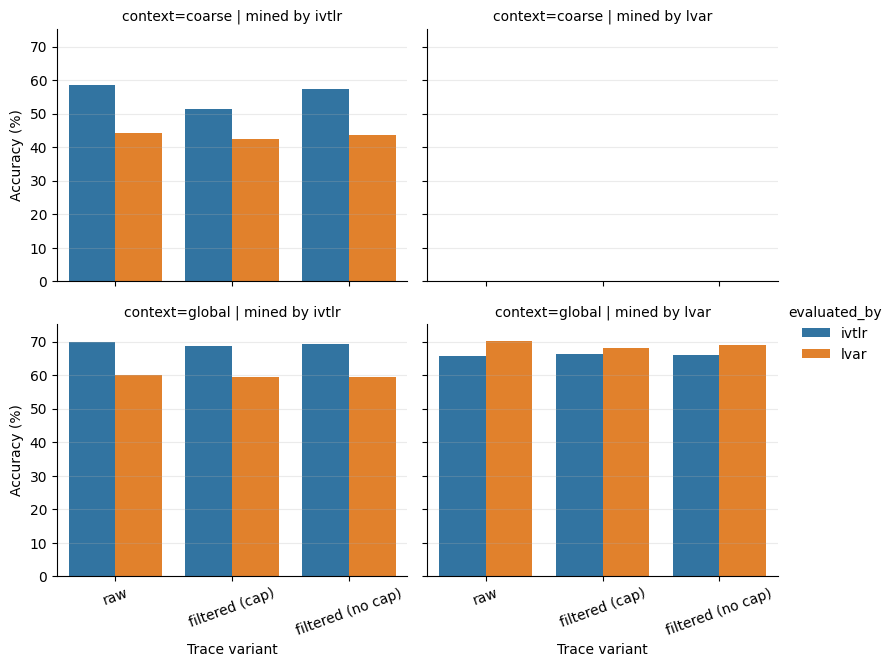

In [11]:
variant_order = ["raw", "filtered (cap)", "filtered (no cap)"]
plot_df = accuracy_df.copy()
plot_df["run"] = (
    "mined=" + plot_df["mined_by"].astype(str)
    + " | eval=" + plot_df["evaluated_by"].astype(str)
    + " | " + plot_df["context"].astype(str)
)
plot_df["trace_variant_label"] = pd.Categorical(plot_df["trace_variant_label"], categories=variant_order, ordered=True)
plot_df = plot_df.sort_values(["context", "mined_by", "evaluated_by", "trace_variant_label"])

if HAS_SEABORN:
    g = sns.catplot(
        data=plot_df,
        kind="bar",
        x="trace_variant_label",
        y="accuracy",
        hue="evaluated_by",
        col="mined_by",
        row="context",
        order=variant_order,
        height=3.2,
        aspect=1.25,
        sharey=True,
    )
    g.set_axis_labels("Trace variant", "Accuracy (%)")
    g.set_titles(row_template="context={row_name}", col_template="mined by {col_name}")
    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=20)
        ax.set_ylim(0, max(75, plot_df["accuracy"].max() + 5))
    plt.show()
else:
    ax = plot_df.pivot_table(index="run", columns="trace_variant_label", values="accuracy", aggfunc="first")[variant_order].plot(kind="bar", figsize=(13, 6))
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Accuracy by inference setting")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [13]:
best_by_setting = (
    accuracy_df
    .sort_values("accuracy", ascending=False)
    .loc[:, ["mined_by", "context", "evaluated_by", "trace_variant_label", "accuracy", "correct", "total", "avg_trace_actions"]]
    .reset_index(drop=True)
)
best_by_setting.style.format({"accuracy": "{:.2f}", "avg_trace_actions": "{:.2f}"}).set_caption("Inference settings ranked by accuracy")

,mined_by,context,evaluated_by,trace_variant_label,accuracy,correct,total,avg_trace_actions
0,lvar,global,lvar,raw,70.23,1628,2318,8.79
1,ivtlr,global,ivtlr,raw,69.93,1621,2318,8.60
2,ivtlr,global,ivtlr,filtered (no cap),69.41,1609,2318,7.64
3,lvar,global,lvar,filtered (no cap),68.94,1598,2318,7.72
4,ivtlr,global,ivtlr,filtered (cap),68.68,1592,2318,6.36
5,lvar,global,lvar,filtered (cap),67.99,1576,2318,6.46
6,lvar,global,ivtlr,filtered (cap),66.26,1536,2318,6.46
7,lvar,global,ivtlr,filtered (no cap),66.05,1531,2318,7.72
8,lvar,global,ivtlr,raw,65.66,1522,2318,8.79
9,ivtlr,global,lvar,raw,60.22,1396,2318,8.60


## 2. Load The Four Test Traces

The four mined trace sets are expected to be `(lvar, global)`, `(lvar, coarse)`, `(ivtlr, global)`, and `(ivtlr, coarse)`. The loader below also reports missing summaries, because the `lvar/coarse` trace file may not have a sibling summary JSON.

In [14]:
trace_files = sorted(TRACE_ROOT.rglob("m3cot_test_traces_*_*.jsonl"))
trace_manifest_rows = []
trace_records = []
bad_trace_rows = []

for path in trace_files:
    mined_by, context = parse_trace_path(path)
    summary_path = path.with_name(path.stem + "_summary.json")
    summary = load_json(summary_path) if summary_path.exists() else {}
    rows, bad_rows = load_jsonl(path)
    bad_trace_rows.extend(bad_rows)
    trace_manifest_rows.append({
        "mined_by": mined_by,
        "context": context,
        "num_rows_loaded": len(rows),
        "summary_exists": summary_path.exists(),
        "summary_num_examples": summary.get("num_examples"),
        "summary_num_decisions": summary.get("num_decisions"),
        "summary_mean_selected_improvement": summary.get("mean_selected_improvement"),
        "initial_visual_mode": summary.get("initial_visual_mode") or (rows[0].get("initial_visual_mode") if rows else None),
        "trace_path": str(path.relative_to(ROOT)),
        "summary_path": str(summary_path.relative_to(ROOT)) if summary_path.exists() else None,
    })
    for row in rows:
        rec = dict(row)
        rec["mined_by"] = mined_by
        rec["context"] = context
        rec["trace_file"] = str(path.relative_to(ROOT))
        trace_records.append(rec)

trace_manifest = pd.DataFrame(trace_manifest_rows).sort_values(["mined_by", "context"]).reset_index(drop=True)
print(f"Trace files loaded: {len(trace_files)}")
print(f"Trace rows loaded: {len(trace_records):,}")
print(f"Bad JSONL rows: {len(bad_trace_rows):,}")
trace_manifest

Trace files loaded: 4
Trace rows loaded: 7,754
Bad JSONL rows: 0


,mined_by,context,num_rows_loaded,summary_exists,summary_num_examples,summary_num_decisions,summary_mean_selected_improvement,initial_visual_mode,trace_path,summary_path
0,ivtlr,coarse,2318,True,2318.0,14905.0,0.108189,global_mean,outputs/oracle_dataset/test/ivtlr_ckpt/m3cot_test_traces_ivtlr_coarse.jsonl,outputs/oracle_dataset/test/ivtlr_ckpt/m3cot_test_traces_ivtlr_coarse_summary.json
1,ivtlr,global,2318,True,2318.0,14712.0,0.067252,full_context,outputs/oracle_dataset/test/ivtlr_ckpt/m3cot_test_traces_ivtlr_global.jsonl,outputs/oracle_dataset/test/ivtlr_ckpt/m3cot_test_traces_ivtlr_global_summary.json
2,lvar,coarse,800,False,NaN,NaN,NaN,global_mean,outputs/oracle_dataset/test/lvar_ckpt/m3cot_test_traces_lvar_coarse.jsonl,None
3,lvar,global,2318,True,2318.0,14905.0,0.076528,full_context,outputs/oracle_dataset/test/lvar_ckpt/m3cot_test_traces_lvar_global.jsonl,outputs/oracle_dataset/test/lvar_ckpt/m3cot_test_traces_lvar_global_summary.json


In [15]:
expected_trace_keys = pd.MultiIndex.from_product([['ivtlr', 'lvar'], ['coarse', 'global']], names=['mined_by', 'context'])
actual_trace_keys = pd.MultiIndex.from_frame(trace_manifest[['mined_by', 'context']])
missing_trace_keys = expected_trace_keys.difference(actual_trace_keys)
print("Expected four trace sets present?", len(missing_trace_keys) == 0)
if len(missing_trace_keys):
    print("Missing:")
    display(missing_trace_keys.to_frame(index=False))

Expected four trace sets present? True


## Flatten Trace Metrics

`trace_examples` is one row per example per mined trace set. `trace_actions` is one row per primitive action. `trace_decisions` is one row per mined decision step. These are the core tables used below.

In [16]:
example_rows = []
action_rows = []
decision_rows = []
counterfactual_rows = []

for row in trace_records:
    mined_by = row["mined_by"]
    context = row["context"]
    example_id = row.get("example_id")
    decisions = row.get("decisions") or []
    trace = row.get("trace") or []
    steps = row.get("steps") or []
    question = row.get("question")

    reductions = [decision_reduction(d) for d in decisions]
    ce_noop_values = [d.get("ce_noop") for d in decisions if d.get("ce_noop") is not None]
    ce_selected_values = [d.get("ce_selected") for d in decisions if d.get("ce_selected") is not None]
    selected_names = [str(d.get("selected", "UNKNOWN")).upper() for d in decisions]
    decision_action_lengths = [len(d.get("actions") or []) for d in decisions]

    primitive_types = [action_type(a) for a in trace]
    primitive_no_stop = [t for t in primitive_types if t != "STOP"]
    patch_indices = [action_index(a) for a in trace if action_type(a) == "PATCH"]
    region_indices = [action_index(a) for a in trace if action_type(a) == "REGION"]

    example_rows.append({
        "mined_by": mined_by,
        "context": context,
        "example_id": example_id,
        "answer": row.get("answer"),
        "num_steps": len(steps),
        "num_decisions": len(decisions),
        "num_trace_actions_with_stop": len(trace),
        "num_trace_actions": len(primitive_no_stop),
        "num_patches": sum(1 for t in primitive_types if t == "PATCH"),
        "num_regions": sum(1 for t in primitive_types if t == "REGION"),
        "num_think": sum(1 for t in primitive_types if t == "THINK"),
        "has_stop": any(t == "STOP" for t in primitive_types),
        "num_noop_decisions": sum(1 for name, d in zip(selected_names, decisions) if name == "NO_OP" or not (d.get("actions") or [])),
        "num_positive_decisions": sum(1 for r in reductions if pd.notna(r) and r > 0),
        "total_ce_noop": finite_sum(ce_noop_values),
        "total_ce_selected": finite_sum(ce_selected_values),
        "total_ce_reduction": finite_sum(reductions),
        "mean_ce_reduction": finite_mean(reductions),
        "max_ce_reduction": max([r for r in reductions if pd.notna(r)], default=np.nan),
        "mean_decision_action_length": finite_mean(decision_action_lengths),
        "selected_decisions": selected_names,
        "primitive_action_types": primitive_types,
        "patch_indices": patch_indices,
        "region_indices": region_indices,
        "question": question,
    })

    for decision_idx, decision in enumerate(decisions):
        selected = str(decision.get("selected", "UNKNOWN")).upper()
        reduction = decision_reduction(decision)
        actions = decision.get("actions") or []
        decision_rows.append({
            "mined_by": mined_by,
            "context": context,
            "example_id": example_id,
            "decision_idx": decision_idx,
            "step_idx": decision.get("step_idx"),
            "selected": selected,
            "num_actions": len(actions),
            "ce_noop": decision.get("ce_noop"),
            "ce_selected": decision.get("ce_selected"),
            "ce_reduction": reduction,
            "is_noop": selected == "NO_OP" or len(actions) == 0,
        })

    for action_idx, action in enumerate(trace):
        typ = action_type(action)
        action_rows.append({
            "mined_by": mined_by,
            "context": context,
            "example_id": example_id,
            "action_idx": action_idx,
            "action_type": typ,
            "patch_idx": action_index(action) if typ == "PATCH" else np.nan,
            "region_idx": action_index(action) if typ == "REGION" else np.nan,
        })

    for pair_idx, pair in enumerate(row.get("counterfactual_pairs") or []):
        for polarity, actions_key in [("positive", "positive_actions"), ("negative", "negative_actions")]:
            for action_pos, action in enumerate(pair.get(actions_key) or []):
                typ = action_type(action)
                counterfactual_rows.append({
                    "mined_by": mined_by,
                    "context": context,
                    "example_id": example_id,
                    "pair_idx": pair_idx,
                    "step_idx": pair.get("step_idx"),
                    "polarity": polarity,
                    "action_pos": action_pos,
                    "action_type": typ,
                    "patch_idx": action_index(action) if typ == "PATCH" else np.nan,
                    "region_idx": action_index(action) if typ == "REGION" else np.nan,
                })

trace_examples = pd.DataFrame(example_rows)
trace_actions = pd.DataFrame(action_rows)
trace_decisions = pd.DataFrame(decision_rows)
trace_counterfactual_actions = pd.DataFrame(counterfactual_rows)

print("trace_examples", trace_examples.shape)
print("trace_actions", trace_actions.shape)
print("trace_decisions", trace_decisions.shape)
print("trace_counterfactual_actions", trace_counterfactual_actions.shape)
trace_examples.head()

trace_examples (7754, 25)
trace_actions (75458, 7)
trace_decisions (49019, 11)
trace_counterfactual_actions (134532, 10)


,mined_by,context,example_id,answer,num_steps,num_decisions,num_trace_actions_with_stop,num_trace_actions,num_patches,num_regions,num_think,has_stop,num_noop_decisions,num_positive_decisions,total_ce_noop,total_ce_selected,total_ce_reduction,mean_ce_reduction,max_ce_reduction,mean_decision_action_length,selected_decisions,primitive_action_types,patch_indices,region_indices,question
0,ivtlr,coarse,physical-commonsense-1398,B,4,4,7,6,4,1,1,True,1,3,6.867413,6.403317,0.464096,0.116024,0.270759,1.500000,"[REGION, PATCH_SEQ, PATCH_SEQ_THINK, NO_OP]","[REGION, PATCH, PATCH, PATCH, PATCH, THINK, STOP]","[44, 69, 3, 29]",[13],[Question]:{What is the likely purpose of the troll statue under the bridge?}\n[Options]:\n(A).{To scare away trespassers}\n(B).{To brin...
1,ivtlr,coarse,physical-commonsense-1342,B,3,3,5,4,0,2,1,True,0,3,3.575614,2.948895,0.626719,0.208906,0.305506,1.333333,"[REGION, GLOBAL_THINK, REGION]","[REGION, GLOBAL, THINK, REGION, STOP]",[],"[5, 18]",[Question]:{What is the primary business of the truck?}\n[Options]:\n(A).{Transporting clothing}\n(B).{Selling food}\n(C).{Selling books...
2,ivtlr,coarse,physical-commonsense-1423,C,6,6,9,8,2,4,2,True,0,6,18.513145,17.026136,1.487009,0.247835,0.457760,1.333333,"[REGION, PATCH_SEQ, REGION, REGION, THINK, REGION_THINK]","[REGION, PATCH, PATCH, REGION, REGION, THINK, REGION, THINK, STOP]","[16, 14]","[21, 24, 19, 24]",[Question]:{What kind of snowboarders is the mountain in the picture suitable for?}\n[Options]:\n(A).{Beginner only}\n(B).{Not sure}\n(C...
3,ivtlr,coarse,physical-commonsense-1364,B,3,3,3,2,0,1,1,True,2,1,3.418357,3.280696,0.137661,0.045887,0.137661,0.666667,"[NO_OP, NO_OP, REGION_THINK]","[REGION, THINK, STOP]",[],[6],[Question]:{What is the purpose of the red train cart?}\n[Options]:\n(A).{Transporting cargo}\n(B).{Providing living quarters}\n(C).{Car...
4,ivtlr,coarse,physical-commonsense-1350,C,4,4,8,7,4,2,1,True,1,3,8.134082,7.519597,0.614484,0.153621,0.412117,1.750000,"[REGION, REGION, PATCH_SEQ_THINK, NO_OP]","[REGION, REGION, PATCH, PATCH, PATCH, PATCH, THINK, STOP]","[69, 59, 18, 0]","[8, 2]",[Question]:{What is the possible purpose of the building in the background?}\n[Options]:\n(A).{A shopping mall}\n(B).{A bird museum}\n(C...


## Side-By-Side Trace Overview

This summarizes length, selected visual primitives, NO_OP usage, and total cross-entropy reduction for each of the four trace sets.

In [17]:
trace_overview = (
    trace_examples
    .groupby(["mined_by", "context"])
    .agg(
        examples=("example_id", "nunique"),
        avg_steps=("num_steps", "mean"),
        avg_decisions=("num_decisions", "mean"),
        avg_trace_actions=("num_trace_actions", "mean"),
        median_trace_actions=("num_trace_actions", "median"),
        avg_patches=("num_patches", "mean"),
        avg_regions=("num_regions", "mean"),
        avg_think=("num_think", "mean"),
        avg_noop_decisions=("num_noop_decisions", "mean"),
        avg_positive_decisions=("num_positive_decisions", "mean"),
        avg_total_ce_reduction=("total_ce_reduction", "mean"),
        median_total_ce_reduction=("total_ce_reduction", "median"),
        avg_mean_step_reduction=("mean_ce_reduction", "mean"),
    )
    .reset_index()
)
trace_overview.style.format({
    "avg_steps": "{:.2f}",
    "avg_decisions": "{:.2f}",
    "avg_trace_actions": "{:.2f}",
    "median_trace_actions": "{:.1f}",
    "avg_patches": "{:.2f}",
    "avg_regions": "{:.2f}",
    "avg_think": "{:.2f}",
    "avg_noop_decisions": "{:.2f}",
    "avg_positive_decisions": "{:.2f}",
    "avg_total_ce_reduction": "{:.4f}",
    "median_total_ce_reduction": "{:.4f}",
    "avg_mean_step_reduction": "{:.4f}",
})

,mined_by,context,examples,avg_steps,avg_decisions,avg_trace_actions,median_trace_actions,avg_patches,avg_regions,avg_think,avg_noop_decisions,avg_positive_decisions,avg_total_ce_reduction,median_total_ce_reduction,avg_mean_step_reduction
0,ivtlr,coarse,2318,6.43,6.43,10.57,10.0,7.26,2.43,0.84,1.19,5.24,0.6957,0.6258,0.1156
1,ivtlr,global,2318,6.43,6.43,7.60,7.0,4.85,2.02,0.69,2.39,4.04,0.4339,0.3943,0.0736
2,lvar,coarse,800,5.38,5.38,9.42,9.0,6.75,1.98,0.62,0.68,4.70,0.8078,0.7087,0.1632
3,lvar,global,2318,6.43,6.43,7.79,7.0,5.29,1.79,0.62,2.34,4.09,0.4921,0.4186,0.0875


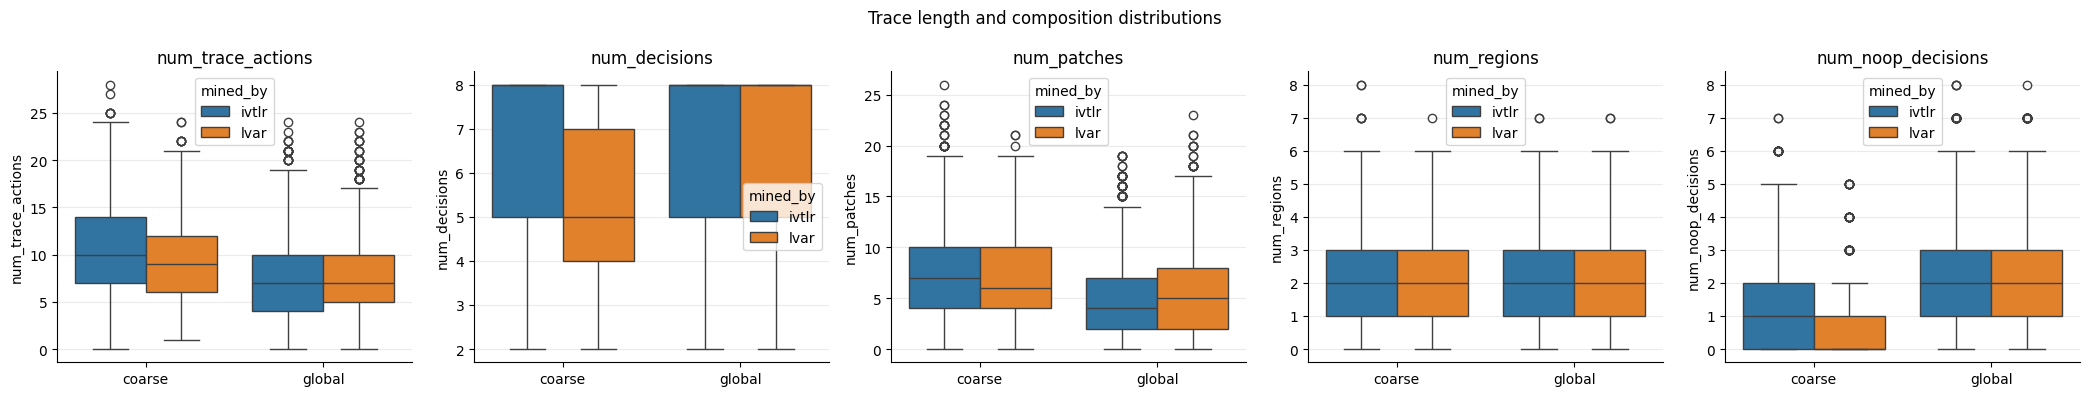

In [18]:
length_cols = ["num_trace_actions", "num_decisions", "num_patches", "num_regions", "num_noop_decisions"]
fig, axes = plt.subplots(1, len(length_cols), figsize=(4.2 * len(length_cols), 4), sharey=False)
for ax, col in zip(axes, length_cols):
    if HAS_SEABORN:
        sns.boxplot(data=trace_examples, x="context", y=col, hue="mined_by", ax=ax)
    else:
        trace_examples.boxplot(column=col, by=["mined_by", "context"], ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("Trace length and composition distributions")
plt.tight_layout()
plt.show()

## Action And Decision Distributions

Primitive actions come from the final trace sequence. High-level decisions come from the mining controller's selected decision at each reasoning step.

In [19]:
action_dist = (
    trace_actions[trace_actions["action_type"] != "STOP"]
    .groupby(["mined_by", "context", "action_type"])
    .size()
    .rename("count")
    .reset_index()
)
action_dist["share_within_trace_set"] = action_dist["count"] / action_dist.groupby(["mined_by", "context"])["count"].transform("sum")
action_pivot = action_dist.pivot_table(index=["mined_by", "context"], columns="action_type", values="share_within_trace_set", fill_value=0)
action_pivot.style.format("{:.2%}").set_caption("Primitive action distribution by trace set")

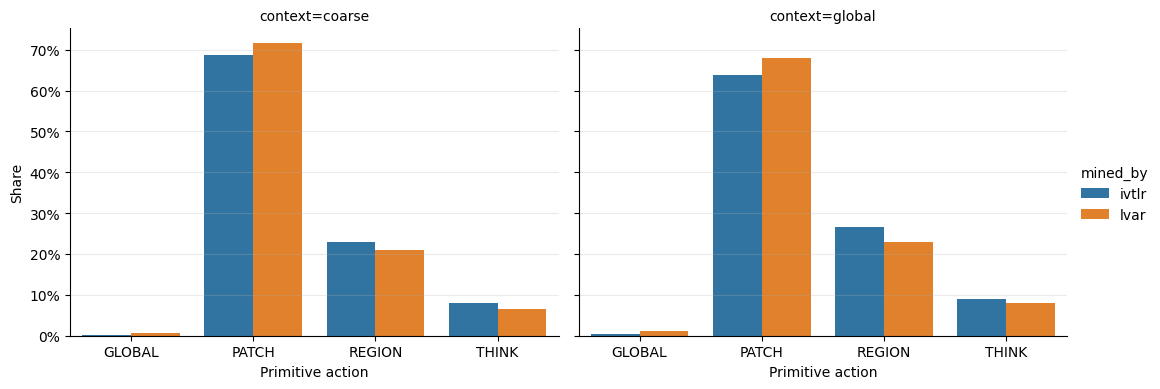

In [20]:
if HAS_SEABORN:
    g = sns.catplot(
        data=action_dist,
        kind="bar",
        x="action_type",
        y="share_within_trace_set",
        hue="mined_by",
        col="context",
        height=4,
        aspect=1.35,
    )
    g.set_axis_labels("Primitive action", "Share")
    g.set_titles("context={col_name}")
    for ax in g.axes.flat:
        ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    plt.show()
else:
    action_pivot.plot(kind="bar", figsize=(10, 5))
    plt.ylabel("Share")
    plt.tight_layout()
    plt.show()

In [21]:
decision_dist = (
    trace_decisions
    .groupby(["mined_by", "context", "selected"])
    .size()
    .rename("count")
    .reset_index()
)
decision_dist["share_within_trace_set"] = decision_dist["count"] / decision_dist.groupby(["mined_by", "context"])["count"].transform("sum")
decision_pivot = decision_dist.pivot_table(index=["mined_by", "context"], columns="selected", values="share_within_trace_set", fill_value=0)
decision_pivot.style.format("{:.2%}").set_caption("High-level selected decision distribution by trace set")

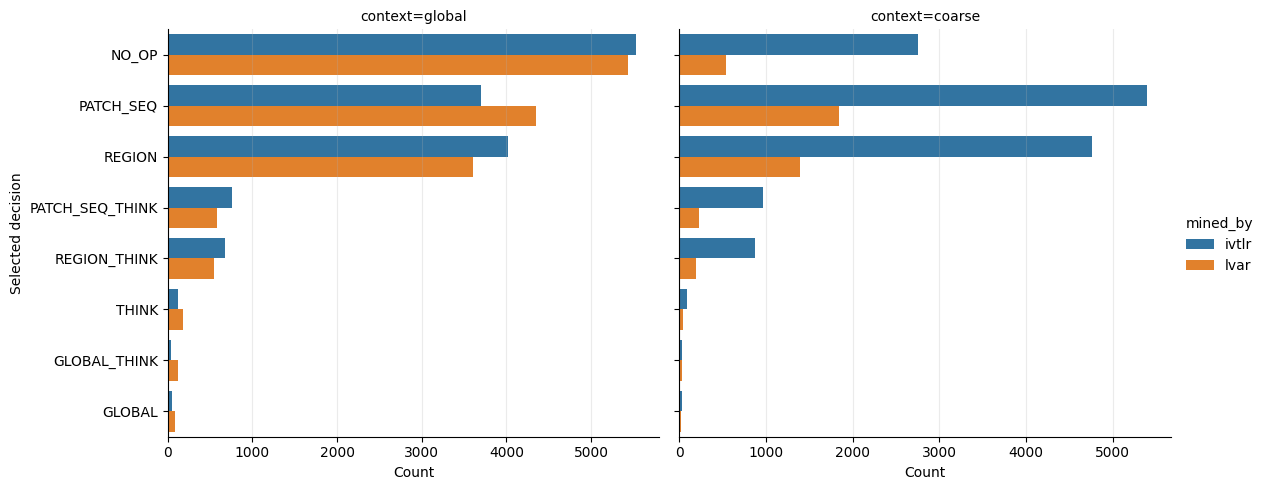

In [22]:
top_decisions = decision_dist.sort_values("count", ascending=False).head(40)
if HAS_SEABORN:
    g = sns.catplot(
        data=top_decisions,
        kind="bar",
        y="selected",
        x="count",
        hue="mined_by",
        col="context",
        height=5,
        aspect=1.2,
        sharex=False,
    )
    g.set_axis_labels("Count", "Selected decision")
    g.set_titles("context={col_name}")
    plt.show()
else:
    decision_dist.pivot_table(index="selected", columns=["mined_by", "context"], values="count", fill_value=0).plot(kind="barh", figsize=(11, 7))
    plt.tight_layout()
    plt.show()

## Selected Patches And Regions

This section shows which patch and region indices were selected most often, including heatmaps when indices form a square-ish grid. The counterfactual table compares selected positive actions against the sampled negative alternatives from mining.

In [23]:
def top_index_table(df, index_col, label, top_n=15):
    out = (
        df.dropna(subset=[index_col])
        .assign(**{index_col: lambda x: x[index_col].astype(int)})
        .groupby(["mined_by", "context", index_col])
        .size()
        .rename("count")
        .reset_index()
        .sort_values(["mined_by", "context", "count"], ascending=[True, True, False])
    )
    out["rank"] = out.groupby(["mined_by", "context"])["count"].rank(method="first", ascending=False).astype(int)
    return out[out["rank"] <= top_n].rename(columns={index_col: label})

selected_patch_top = top_index_table(trace_actions[trace_actions["action_type"] == "PATCH"], "patch_idx", "patch_idx")
selected_region_top = top_index_table(trace_actions[trace_actions["action_type"] == "REGION"], "region_idx", "region_idx")

print("Top selected patches")
display(selected_patch_top)
print("Top selected regions")
display(selected_region_top)

Top selected patches


,mined_by,context,patch_idx,count,rank
99,ivtlr,coarse,99,416,1
89,ivtlr,coarse,89,337,2
91,ivtlr,coarse,91,309,3
90,ivtlr,coarse,90,288,4
81,ivtlr,coarse,81,271,5
92,ivtlr,coarse,92,265,6
96,ivtlr,coarse,96,248,7
82,ivtlr,coarse,82,244,8
97,ivtlr,coarse,97,244,9
94,ivtlr,coarse,94,241,10


Top selected regions


,mined_by,context,region_idx,count,rank
20,ivtlr,coarse,20,455,1
24,ivtlr,coarse,24,394,2
21,ivtlr,coarse,21,331,3
22,ivtlr,coarse,22,289,4
15,ivtlr,coarse,15,286,5
5,ivtlr,coarse,5,251,6
23,ivtlr,coarse,23,242,7
16,ivtlr,coarse,16,231,8
1,ivtlr,coarse,1,225,9
11,ivtlr,coarse,11,225,10


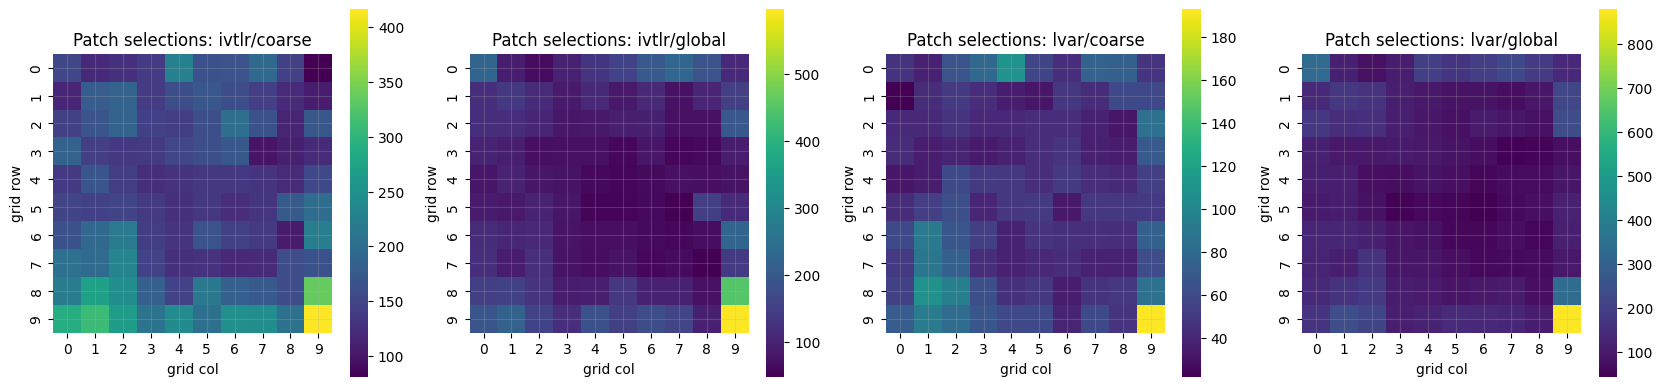

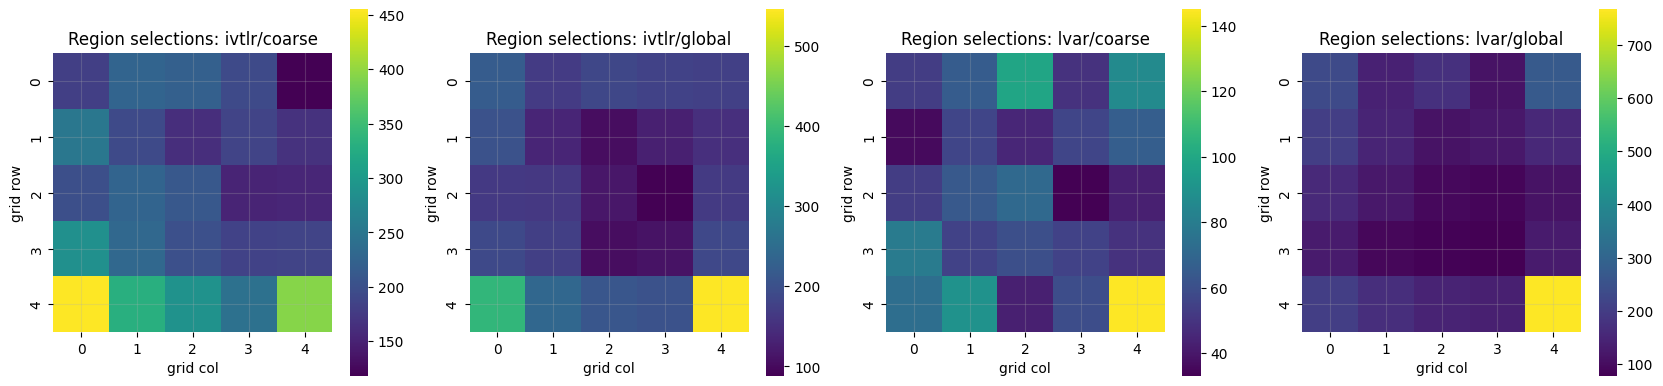

In [24]:
def plot_index_heatmaps(df, index_col, title_prefix):
    usable = df.dropna(subset=[index_col]).copy()
    if usable.empty:
        print(f"No indices available for {index_col}")
        return
    usable[index_col] = usable[index_col].astype(int)
    groups = list(usable.groupby(["mined_by", "context"]))
    fig, axes = plt.subplots(1, len(groups), figsize=(4.2 * len(groups), 4), squeeze=False)
    for ax, ((mined_by, context), group) in zip(axes.flat, groups):
        n = infer_grid_size(group[index_col].tolist())
        grid = np.zeros((n, n), dtype=float)
        counts = group[index_col].value_counts()
        for idx, count in counts.items():
            grid[int(idx) // n, int(idx) % n] = count
        if HAS_SEABORN:
            sns.heatmap(grid, ax=ax, cmap="viridis", cbar=True, square=True)
        else:
            im = ax.imshow(grid, cmap="viridis")
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(f"{title_prefix}: {mined_by}/{context}")
        ax.set_xlabel("grid col")
        ax.set_ylabel("grid row")
    plt.tight_layout()
    plt.show()

plot_index_heatmaps(trace_actions[trace_actions["action_type"] == "PATCH"], "patch_idx", "Patch selections")
plot_index_heatmaps(trace_actions[trace_actions["action_type"] == "REGION"], "region_idx", "Region selections")

In [25]:
cf_summary = (
    trace_counterfactual_actions
    .groupby(["mined_by", "context", "polarity", "action_type"])
    .size()
    .rename("count")
    .reset_index()
)
cf_summary["share"] = cf_summary["count"] / cf_summary.groupby(["mined_by", "context", "polarity"])["count"].transform("sum")
cf_summary.pivot_table(index=["mined_by", "context", "polarity"], columns="action_type", values="share", fill_value=0).style.format("{:.2%}").set_caption("Counterfactual positive vs negative action distribution")

## Cross-Entropy Reduction

`total_ce_reduction` is the sum over mined decisions of `ce_noop - ce_selected` (or the stored `improvement`). This captures the total reduction in target continuation cross entropy attributable to the selected trace decisions for an example.

In [26]:
ce_summary = (
    trace_examples
    .groupby(["mined_by", "context"])
    .agg(
        examples=("example_id", "nunique"),
        mean_total_reduction=("total_ce_reduction", "mean"),
        median_total_reduction=("total_ce_reduction", "median"),
        std_total_reduction=("total_ce_reduction", "std"),
        p10_total_reduction=("total_ce_reduction", lambda s: s.quantile(0.10)),
        p90_total_reduction=("total_ce_reduction", lambda s: s.quantile(0.90)),
        mean_step_reduction=("mean_ce_reduction", "mean"),
        mean_positive_decisions=("num_positive_decisions", "mean"),
    )
    .reset_index()
)
ce_summary.style.format({c: "{:.4f}" for c in ce_summary.columns if c not in ["mined_by", "context", "examples"]})

,mined_by,context,examples,mean_total_reduction,median_total_reduction,std_total_reduction,p10_total_reduction,p90_total_reduction,mean_step_reduction,mean_positive_decisions
0,ivtlr,coarse,2318,0.6957,0.6258,0.3704,0.3038,1.1822,0.1156,5.2433
1,ivtlr,global,2318,0.4339,0.3943,0.2596,0.1488,0.7740,0.0736,4.0444
2,lvar,coarse,800,0.8078,0.7087,0.4429,0.3482,1.3743,0.1632,4.7038
3,lvar,global,2318,0.4921,0.4186,0.3071,0.1719,0.9108,0.0875,4.0867


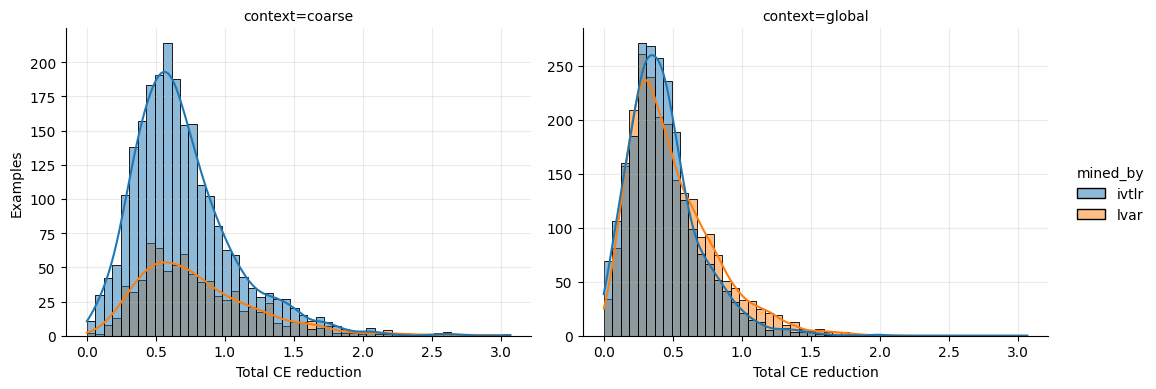

In [27]:
if HAS_SEABORN:
    g = sns.displot(
        data=trace_examples,
        x="total_ce_reduction",
        hue="mined_by",
        col="context",
        kind="hist",
        bins=50,
        kde=True,
        height=4,
        aspect=1.35,
        facet_kws={"sharex": True, "sharey": False},
    )
    g.set_axis_labels("Total CE reduction", "Examples")
    g.set_titles("context={col_name}")
    plt.show()
else:
    for (mined_by, context), group in trace_examples.groupby(["mined_by", "context"]):
        plt.hist(group["total_ce_reduction"], bins=50, alpha=0.45, label=f"{mined_by}/{context}")
    plt.xlabel("Total CE reduction")
    plt.ylabel("Examples")
    plt.legend()
    plt.show()

In [28]:
step_reduction_summary = (
    trace_decisions
    .groupby(["mined_by", "context", "selected"])
    .agg(
        decisions=("ce_reduction", "size"),
        mean_reduction=("ce_reduction", "mean"),
        median_reduction=("ce_reduction", "median"),
        positive_rate=("ce_reduction", lambda s: (s > 0).mean()),
    )
    .reset_index()
    .sort_values(["mined_by", "context", "mean_reduction"], ascending=[True, True, False])
)
step_reduction_summary.style.format({"mean_reduction": "{:.4f}", "median_reduction": "{:.4f}", "positive_rate": "{:.2%}"}).set_caption("CE reduction by selected high-level decision")

,mined_by,context,selected,decisions,mean_reduction,median_reduction,positive_rate
7,ivtlr,coarse,THINK,87,0.1988,0.1434,100.00%
4,ivtlr,coarse,PATCH_SEQ_THINK,962,0.1607,0.1095,100.00%
6,ivtlr,coarse,REGION_THINK,872,0.1519,0.1064,100.00%
1,ivtlr,coarse,GLOBAL_THINK,36,0.1464,0.1125,100.00%
3,ivtlr,coarse,PATCH_SEQ,5399,0.1280,0.1009,100.00%
5,ivtlr,coarse,REGION,4763,0.1278,0.1029,100.00%
0,ivtlr,coarse,GLOBAL,35,0.0913,0.0859,100.00%
2,ivtlr,coarse,NO_OP,2751,0.0000,0.0000,0.00%
9,ivtlr,global,GLOBAL_THINK,40,0.1389,0.1099,100.00%
15,ivtlr,global,THINK,128,0.1361,0.0763,100.00%


## 3. Correct vs Incorrect Inference Outcomes

This loads every prediction JSONL, joins correctness back to the mined trace features by `(mined_by, context, example_id)`, and compares mined CE reductions for examples answered correctly vs incorrectly under each evaluator and trace variant.

In [38]:
prediction_rows = []
bad_prediction_rows = []

for summary_path in sorted(INFERENCE_ROOT.rglob("*_summary.json")):
    summary = load_json(summary_path)
    mined_by, evaluated_by, variant_from_path = parse_inference_summary_path(summary_path)
    trace_variant = summary.get("trace_variant") or variant_from_path
    output_path = Path(summary.get("output_path", ""))
    if not output_path.is_absolute():
        output_path = ROOT / output_path
    if not output_path.exists():
        print(f"Missing prediction file: {output_path}")
        continue
    rows, bad_rows = load_jsonl(output_path)
    bad_prediction_rows.extend(bad_rows)
    for row in rows:
        prediction_rows.append({
            "mined_by": mined_by,
            "context": summary.get("context") or row.get("context"),
            "evaluated_by": evaluated_by,
            "trace_variant": trace_variant,
            "trace_variant_label": pretty_variant(trace_variant),
            "example_id": row.get("example_id"),
            "correct": bool(row.get("correct")),
            "gold_answer": row.get("gold_answer"),
            "raw_answer": row.get("raw_answer"),
            "generated_text": row.get("generated_text"),
            "decoded_answer": row.get("decoded_answer"),
            "domain": row.get("domain"),
            "topic": row.get("topic"),
            "num_inference_trace_actions": row.get("num_trace_actions"),
            "num_output_tokens": row.get("num_output_tokens"),
            "kept_primitives": (row.get("transform") or {}).get("kept_primitives"),
            "cap_applied": (row.get("transform") or {}).get("cap_applied"),
            "prediction_path": str(output_path.relative_to(ROOT)),
        })

predictions = pd.DataFrame(prediction_rows)
print("prediction rows", predictions.shape)
print("bad prediction rows", len(bad_prediction_rows))
predictions.head()

prediction rows (41724, 18)
bad prediction rows 0


,mined_by,context,evaluated_by,trace_variant,trace_variant_label,example_id,correct,gold_answer,raw_answer,generated_text,decoded_answer,domain,topic,num_inference_trace_actions,num_output_tokens,kept_primitives,cap_applied,prediction_path
0,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1398,False,b,B,"Therefore, the answer is D","Therefore, the answer is D",commonsense,physical-commonsense,7,6,7,True,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...
1,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1342,True,b,B,"Therefore, the answer is B","Therefore, the answer is B",commonsense,physical-commonsense,5,6,5,True,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...
2,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1423,True,c,C,"Therefore, the answer is C","Therefore, the answer is C",commonsense,physical-commonsense,7,6,7,True,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...
3,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1364,False,b,B,"Therefore, the answer is C","Therefore, the answer is C",commonsense,physical-commonsense,3,6,3,True,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...
4,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1350,False,c,C,"Therefore, the answer is D","Therefore, the answer is D",commonsense,physical-commonsense,8,6,8,True,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...


In [30]:
join_cols = ["mined_by", "context", "example_id"]
trace_features = trace_examples.drop(columns=["selected_decisions", "primitive_action_types", "patch_indices", "region_indices"], errors="ignore")
correctness_traces = predictions.merge(trace_features, on=join_cols, how="left", suffixes=("_pred", "_trace"))

missing_trace_join = correctness_traces["total_ce_reduction"].isna().sum()
print(f"Joined prediction rows: {len(correctness_traces):,}")
print(f"Rows missing trace features after join: {missing_trace_join:,}")
correctness_traces.head()

Joined prediction rows: 41,724
Rows missing trace features after join: 0


,mined_by,context,evaluated_by,trace_variant,trace_variant_label,example_id,correct,gold_answer,raw_answer,generated_text,decoded_answer,domain,topic,num_inference_trace_actions,num_output_tokens,kept_primitives,cap_applied,prediction_path,answer,num_steps,num_decisions,num_trace_actions_with_stop,num_trace_actions,num_patches,num_regions,num_think,has_stop,num_noop_decisions,num_positive_decisions,total_ce_noop,total_ce_selected,total_ce_reduction,mean_ce_reduction,max_ce_reduction,mean_decision_action_length,question
0,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1398,False,b,B,"Therefore, the answer is D","Therefore, the answer is D",commonsense,physical-commonsense,7,6,7,True,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...,B,4,4,7,6,4,1,1,True,1,3,6.867413,6.403317,0.464096,0.116024,0.270759,1.500000,[Question]:{What is the likely purpose of the troll statue under the bridge?}\n[Options]:\n(A).{To scare away trespassers}\n(B).{To brin...
1,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1342,True,b,B,"Therefore, the answer is B","Therefore, the answer is B",commonsense,physical-commonsense,5,6,5,True,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...,B,3,3,5,4,0,2,1,True,0,3,3.575614,2.948895,0.626719,0.208906,0.305506,1.333333,[Question]:{What is the primary business of the truck?}\n[Options]:\n(A).{Transporting clothing}\n(B).{Selling food}\n(C).{Selling books...
2,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1423,True,c,C,"Therefore, the answer is C","Therefore, the answer is C",commonsense,physical-commonsense,7,6,7,True,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...,C,6,6,9,8,2,4,2,True,0,6,18.513145,17.026136,1.487009,0.247835,0.457760,1.333333,[Question]:{What kind of snowboarders is the mountain in the picture suitable for?}\n[Options]:\n(A).{Beginner only}\n(B).{Not sure}\n(C...
3,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1364,False,b,B,"Therefore, the answer is C","Therefore, the answer is C",commonsense,physical-commonsense,3,6,3,True,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...,B,3,3,3,2,0,1,1,True,2,1,3.418357,3.280696,0.137661,0.045887,0.137661,0.666667,[Question]:{What is the purpose of the red train cart?}\n[Options]:\n(A).{Transporting cargo}\n(B).{Providing living quarters}\n(C).{Car...
4,ivtlr,coarse,ivtlr,filtered_cap,filtered (cap),physical-commonsense-1350,False,c,C,"Therefore, the answer is D","Therefore, the answer is D",commonsense,physical-commonsense,8,6,8,True,outputs/inference/test_oracle/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_filtered_cap/m3cot_test_predictions_mined-by_ivt...,C,4,4,8,7,4,2,1,True,1,3,8.134082,7.519597,0.614484,0.153621,0.412117,1.750000,[Question]:{What is the possible purpose of the building in the background?}\n[Options]:\n(A).{A shopping mall}\n(B).{A bird museum}\n(C...


In [31]:
correctness_summary = (
    correctness_traces
    .groupby(["mined_by", "context", "evaluated_by", "trace_variant_label", "correct"])
    .agg(
        examples=("example_id", "nunique"),
        mean_total_ce_reduction=("total_ce_reduction", "mean"),
        median_total_ce_reduction=("total_ce_reduction", "median"),
        mean_step_reduction=("mean_ce_reduction", "mean"),
        mean_trace_actions=("num_trace_actions", "mean"),
        mean_patches=("num_patches", "mean"),
        mean_regions=("num_regions", "mean"),
        mean_noop_decisions=("num_noop_decisions", "mean"),
        mean_inference_trace_actions=("num_inference_trace_actions", "mean"),
    )
    .reset_index()
    .sort_values(["mined_by", "context", "evaluated_by", "trace_variant_label", "correct"])
)
correctness_summary.style.format({
    "mean_total_ce_reduction": "{:.4f}",
    "median_total_ce_reduction": "{:.4f}",
    "mean_step_reduction": "{:.4f}",
    "mean_trace_actions": "{:.2f}",
    "mean_patches": "{:.2f}",
    "mean_regions": "{:.2f}",
    "mean_noop_decisions": "{:.2f}",
    "mean_inference_trace_actions": "{:.2f}",
}).set_caption("Mined trace statistics split by correct vs incorrect inference outcomes")

,mined_by,context,evaluated_by,trace_variant_label,correct,examples,mean_total_ce_reduction,median_total_ce_reduction,mean_step_reduction,mean_trace_actions,mean_patches,mean_regions,mean_noop_decisions,mean_inference_trace_actions
0,ivtlr,coarse,ivtlr,filtered (cap),False,1125,0.7161,0.6561,0.1179,11.32,7.81,2.54,1.02,7.83
1,ivtlr,coarse,ivtlr,filtered (cap),True,1193,0.6764,0.5988,0.1135,9.86,6.74,2.33,1.34,7.39
2,ivtlr,coarse,ivtlr,filtered (no cap),False,985,0.6745,0.6252,0.1139,10.90,7.49,2.51,1.09,11.06
3,ivtlr,coarse,ivtlr,filtered (no cap),True,1333,0.7113,0.6261,0.1169,10.32,7.09,2.38,1.26,10.71
4,ivtlr,coarse,ivtlr,raw,False,958,0.6748,0.6232,0.1144,10.83,7.41,2.50,1.10,11.83
5,ivtlr,coarse,ivtlr,raw,True,1360,0.7104,0.6265,0.1165,10.38,7.15,2.38,1.25,11.38
6,ivtlr,coarse,lvar,filtered (cap),False,1333,0.6978,0.6416,0.1161,10.92,7.57,2.47,1.10,7.69
7,ivtlr,coarse,lvar,filtered (cap),True,985,0.6927,0.6057,0.1149,10.08,6.84,2.37,1.30,7.49
8,ivtlr,coarse,lvar,filtered (no cap),False,1304,0.6873,0.6403,0.1154,10.78,7.43,2.48,1.12,11.00
9,ivtlr,coarse,lvar,filtered (no cap),True,1014,0.7065,0.6101,0.1160,10.29,7.04,2.37,1.28,10.67


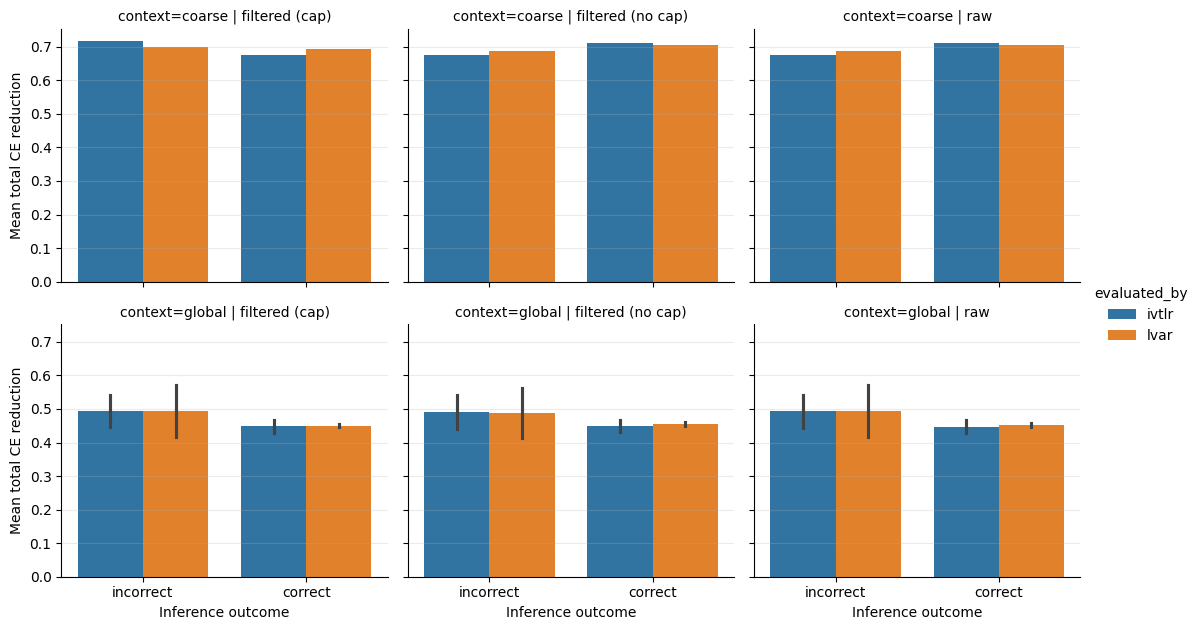

In [32]:
plot_correctness = correctness_summary.copy()
plot_correctness["outcome"] = np.where(plot_correctness["correct"], "correct", "incorrect")
plot_correctness["setting"] = (
    "mined=" + plot_correctness["mined_by"].astype(str)
    + " | eval=" + plot_correctness["evaluated_by"].astype(str)
    + " | " + plot_correctness["context"].astype(str)
    + " | " + plot_correctness["trace_variant_label"].astype(str)
)

if HAS_SEABORN:
    g = sns.catplot(
        data=plot_correctness,
        kind="bar",
        x="outcome",
        y="mean_total_ce_reduction",
        hue="evaluated_by",
        col="trace_variant_label",
        row="context",
        height=3.2,
        aspect=1.15,
        sharey=True,
    )
    g.set_axis_labels("Inference outcome", "Mean total CE reduction")
    g.set_titles(row_template="context={row_name}", col_template="{col_name}")
    plt.show()
else:
    correctness_summary.pivot_table(index=["context", "trace_variant_label", "correct"], columns=["mined_by", "evaluated_by"], values="mean_total_ce_reduction").plot(kind="bar", figsize=(13, 6))
    plt.ylabel("Mean total CE reduction")
    plt.tight_layout()
    plt.show()

Selected rows: 2,318
correct
True     1621
False     697
Name: count, dtype: int64


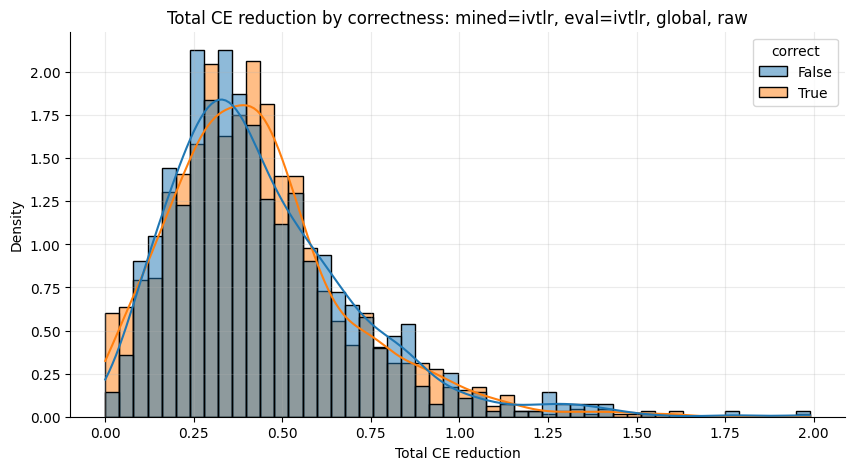

In [33]:
# Pick one setting for a detailed correct-vs-incorrect histogram. Change these selectors as needed.
SELECT_MINED_BY = "ivtlr"
SELECT_CONTEXT = "global"
SELECT_EVALUATED_BY = "ivtlr"
SELECT_TRACE_VARIANT = "raw"

selected_run = correctness_traces[
    (correctness_traces["mined_by"] == SELECT_MINED_BY)
    & (correctness_traces["context"] == SELECT_CONTEXT)
    & (correctness_traces["evaluated_by"] == SELECT_EVALUATED_BY)
    & (correctness_traces["trace_variant"] == SELECT_TRACE_VARIANT)
].copy()

print(f"Selected rows: {len(selected_run):,}")
print(selected_run["correct"].value_counts(dropna=False))

if not selected_run.empty:
    if HAS_SEABORN:
        sns.histplot(data=selected_run, x="total_ce_reduction", hue="correct", bins=50, kde=True, stat="density", common_norm=False)
    else:
        for correct, group in selected_run.groupby("correct"):
            plt.hist(group["total_ce_reduction"], bins=50, alpha=0.45, density=True, label=f"correct={correct}")
        plt.legend()
    plt.title(f"Total CE reduction by correctness: mined={SELECT_MINED_BY}, eval={SELECT_EVALUATED_BY}, {SELECT_CONTEXT}, {SELECT_TRACE_VARIANT}")
    plt.xlabel("Total CE reduction")
    plt.ylabel("Density")
    plt.show()

## Error And Success Examples For Inspection

These tables surface examples where trace mining strongly reduced CE but inference was still wrong, and examples that were correct despite weak or low CE reduction. They are useful candidates for qualitative trace inspection.

In [34]:
def compact_question(text):
    if not isinstance(text, str):
        return text
    text = re.sub(r"\s+", " ", text).strip()
    return text[:260] + ("..." if len(text) > 260 else "")

inspection_cols = [
    "example_id", "topic", "gold_answer", "generated_text", "raw_answer", "total_ce_reduction",
    "num_trace_actions", "num_patches", "num_regions", "num_noop_decisions", "question"
]

if selected_run.empty:
    print("No rows for the selected run. Adjust SELECT_* variables above.")
else:
    display_run = selected_run.copy()
    display_run["question"] = display_run["question"].map(compact_question)

    print("Wrong despite high mined CE reduction")
    display(display_run[~display_run["correct"]].sort_values("total_ce_reduction", ascending=False)[inspection_cols].head(15))

    print("Correct despite low mined CE reduction")
    display(display_run[display_run["correct"]].sort_values("total_ce_reduction", ascending=True)[inspection_cols].head(15))

Wrong despite high mined CE reduction


,example_id,topic,gold_answer,generated_text,raw_answer,total_ce_reduction,num_trace_actions,num_patches,num_regions,num_noop_decisions,question
11716,social-commonsense-1619,social-commonsense,b,"Therefore, the answer is A",B,1.982545,9,5,4,0,[Question]:{Where is the tennis player most likely playing?} [Options]: (A).{In a professional match at a tournament} (B).{In a casual m...
12262,mathematics-879,geometry,c,"Therefore, the answer is D",C,1.770263,7,0,5,1,"[Question]:{If you had to select one option as the correct answer for the Geometry problem shown in the picture, which one would you cho..."
12024,mathematics-1911,temporal-commonsense,d,"Therefore, the answer is C",D,1.519095,14,10,3,0,[Question]:{Look at the following schedule. Hayley just missed the 11.45 AM bus at the boat docks. How long does she have to wait until ...
12534,biology-1053,natural-science,a,"Therefore, the answer is B",A,1.417576,14,8,5,1,"[Question]:{Based on this information, what is Alfalfa's genotype for the horns gene?} [Options]: (A).{HH} (B).{hh} (C).{Hh} Answer:"
11846,social-commonsense-298,social-commonsense,b,"Therefore, the answer is D",B,1.416366,10,9,0,0,"[Question]:{Based on the image, which of the following statements is most likely true about the person who ordered this food?} [Options]..."
12043,mathematics-1597,temporal-commonsense,b,"Therefore, the answer is D",B,1.386698,12,7,3,0,"[Question]:{Franklin is at the art gallery district. If he wants to arrive at the baseball stadium at 12.00 PM, what time should he get ..."
12376,reading-comprehension-20,language-science,a,"Therefore, the answer is B",A,1.373230,10,5,4,1,[Question]:{How do sea otters use their pockets?} [Options]: (A).{Option A in the image} (B).{Option B in the image} (C).{It seems like ...
12552,biology-180,natural-science,d,"Therefore, the answer is A",D,1.334466,10,5,4,1,"[Question]:{Based on this information, what is Bianca's genotype for the eye color gene?} [Options]: (A).{AA} (B).{ee} (C).{Ee} (D).{EE}..."
12399,writing-strategies-101,language-science,b,"Therefore, the answer is A",B,1.316325,17,13,3,0,[Question]:{Which of the following contains a vague pronoun reference?} [Options]: (A).{Option A in the image} (B).{Option B in the imag...
13727,geography-1252,social-science,a,"Therefore, the answer is C",A,1.305454,8,6,1,0,[Question]:{Which of the following fossils is older? Select the more likely answer.} [Options]: (A).{crocodile egg} (B).{fern} (C).{They...


Correct despite low mined CE reduction


,example_id,topic,gold_answer,generated_text,raw_answer,total_ce_reduction,num_trace_actions,num_patches,num_regions,num_noop_decisions,question
11953,mathematics-1580,temporal-commonsense,a,"Therefore, the answer is A",A,0.0,0,0,0,2,[Question]:{Look at the following schedule. When does the shark lecture end?} [Options]: (A).{8:50 AM} (B).{12:10 PM} (C).{12:15 PM} (D)...
12050,mathematics-470,algebra,a,"Therefore, the answer is A",A,0.0,0,0,0,2,"[Question]:{Among the provided choices given in the text, which one represents the accurate answer to the Intermediate Algebra problem i..."
11950,mathematics-1716,temporal-commonsense,c,"Therefore, the answer is C",C,0.0,0,0,0,2,[Question]:{Look at the following schedule. When does the Hawks versus Jaguars game begin?} [Options]: (A).{9:50 AM} (B).{1:55 PM} (C).{...
12104,mathematics-1346,algebra,b,"Therefore, the answer is B",B,0.0,0,0,0,2,"[Question]:{According to the following questions, is option D in the image correct?} [Options]: (A).{False} (B).{True} (C).{Not sure} An..."
12109,mathematics-68,algebra,a,"Therefore, the answer is A",A,0.0,0,0,0,4,"[Question]:{Among the provided choices given in the text, which one represents the accurate answer to the Algebra problem illustrated in..."
12121,mathematics-98,algebra,a,"Therefore, the answer is A",A,0.0,0,0,0,4,[Question]:{This Algebra question has multiple choices given in the text. Which one should I choose?} [Options]: (A).{The listed choices...
13314,cognitive-science-43,social-science,d,"Therefore, the answer is D",D,0.0,0,0,0,3,[Question]:{What does the tangram image depict?} [Options]: (A).{A box} (B).{A goose} (C).{A box with a goose} (D).{A goose with a box} ...
13317,cognitive-science-195,social-science,b,"Therefore, the answer is B",B,0.0,0,0,0,3,[Question]:{What does the Tangram image represent?} [Options]: (A).{A chef} (B).{A geisha girl} (C).{A doctor} (D).{A firefighter} Answer:
11692,social-commonsense-465,social-commonsense,c,"Therefore, the answer is C",C,0.0,0,0,0,2,[Question]:{Where are the people most likely going?} [Options]: (A).{Work} (B).{School} (C).{Sightseeing} (D).{Shopping} Answer:
11838,social-commonsense-1597,social-commonsense,d,"Therefore, the answer is D",D,0.0,0,0,0,4,[Question]:{Which activity was most likely happening in this room before the photo was taken?} [Options]: (A).{Sleeping} (B).{Watching T...


## Domain And Topic Breakdown

This checks whether trace benefit and final correctness vary across M3CoT domains/topics. It can help identify whether a trace setting is helping visual grounding broadly or only for a subset.

In [35]:
domain_summary = (
    correctness_traces
    .groupby(["mined_by", "context", "evaluated_by", "trace_variant_label", "domain"])
    .agg(
        examples=("example_id", "nunique"),
        accuracy=("correct", "mean"),
        mean_total_ce_reduction=("total_ce_reduction", "mean"),
        mean_trace_actions=("num_trace_actions", "mean"),
    )
    .reset_index()
)
domain_summary["accuracy_pct"] = 100 * domain_summary["accuracy"]
domain_summary.sort_values(["trace_variant_label", "accuracy"], ascending=[True, False]).head(40).style.format({
    "accuracy": "{:.4f}",
    "accuracy_pct": "{:.2f}",
    "mean_total_ce_reduction": "{:.4f}",
    "mean_trace_actions": "{:.2f}",
})

,mined_by,context,evaluated_by,trace_variant_label,domain,examples,accuracy,mean_total_ce_reduction,mean_trace_actions,accuracy_pct
18,ivtlr,global,ivtlr,filtered (cap),commonsense,455,0.7692,0.4725,6.24,76.92
45,lvar,global,lvar,filtered (cap),commonsense,455,0.7670,0.5599,6.25,76.70
36,lvar,global,ivtlr,filtered (cap),commonsense,455,0.7560,0.5599,6.25,75.60
27,ivtlr,global,lvar,filtered (cap),commonsense,455,0.6989,0.4725,6.24,69.89
20,ivtlr,global,ivtlr,filtered (cap),science,1622,0.6708,0.4455,8.30,67.08
47,lvar,global,lvar,filtered (cap),science,1622,0.6671,0.4679,8.53,66.71
38,lvar,global,ivtlr,filtered (cap),science,1622,0.6504,0.4679,8.53,65.04
19,ivtlr,global,ivtlr,filtered (cap),mathematics,241,0.6390,0.2828,5.47,63.90
46,lvar,global,lvar,filtered (cap),mathematics,241,0.6017,0.5271,5.68,60.17
29,ivtlr,global,lvar,filtered (cap),science,1622,0.5931,0.4455,8.30,59.31


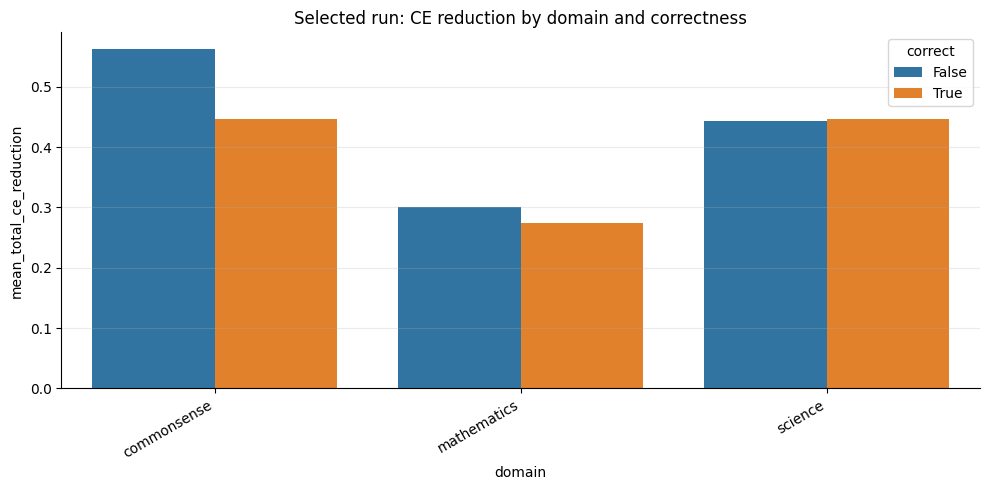

In [36]:
if not selected_run.empty and "domain" in selected_run:
    domain_selected = (
        selected_run
        .groupby(["domain", "correct"])
        .agg(examples=("example_id", "nunique"), mean_total_ce_reduction=("total_ce_reduction", "mean"))
        .reset_index()
    )
    if HAS_SEABORN:
        sns.barplot(data=domain_selected, x="domain", y="mean_total_ce_reduction", hue="correct")
        plt.xticks(rotation=30, ha="right")
        plt.title("Selected run: CE reduction by domain and correctness")
        plt.tight_layout()
        plt.show()
    else:
        domain_selected.pivot_table(index="domain", columns="correct", values="mean_total_ce_reduction").plot(kind="bar", figsize=(10, 5))
        plt.ylabel("Mean total CE reduction")
        plt.tight_layout()
        plt.show()

## Export Analysis Tables

Optional: write the core dataframes as CSVs for reporting or deeper offline analysis.

In [37]:
EXPORT_TABLES = False
EXPORT_DIR = ROOT / "analysis/test_trace_answer_analysis_tables"

if EXPORT_TABLES:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    accuracy_df.to_csv(EXPORT_DIR / "accuracy_by_setting.csv", index=False)
    trace_manifest.to_csv(EXPORT_DIR / "trace_manifest.csv", index=False)
    trace_overview.to_csv(EXPORT_DIR / "trace_overview.csv", index=False)
    ce_summary.to_csv(EXPORT_DIR / "ce_summary.csv", index=False)
    correctness_summary.to_csv(EXPORT_DIR / "correctness_trace_summary.csv", index=False)
    domain_summary.to_csv(EXPORT_DIR / "domain_summary.csv", index=False)
    print(f"Wrote tables to {EXPORT_DIR}")
else:
    print("Set EXPORT_TABLES = True to write CSV outputs.")

Set EXPORT_TABLES = True to write CSV outputs.
